In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'

In [3]:
df = df.replace(-999, np.nan)

In [4]:

df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicate rows: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.248907,3.477046


In [7]:
missing_pct = df.isna().sum() / len(df) * 100
print(missing_pct[missing_pct > 0])  

Series([], dtype: float64)


In [8]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_counts = {}
for col in cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    outliers = np.sum(z > 3)
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers")

# Decision: cap outliers to 3 standard deviations (document in markdown)
for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = df[col].clip(mean - 3*std, mean + 3*std)

T2M: 10 outliers
T2M_MAX: 1 outliers
T2M_MIN: 68 outliers
PRECTOTCORR: 75 outliers
RH2M: 128 outliers
WS2M: 5 outliers
WS2M_MAX: 10 outliers


In [9]:

df[cols] = df[cols].ffill()

df = df.dropna(thresh=int(0.7 * len(df.columns)))
print(f"Final shape: {df.shape}")

Final shape: (4108, 16)


In [10]:
df.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data saved to ../data/nigeria_clean.csv")

Cleaned data saved to ../data/nigeria_clean.csv


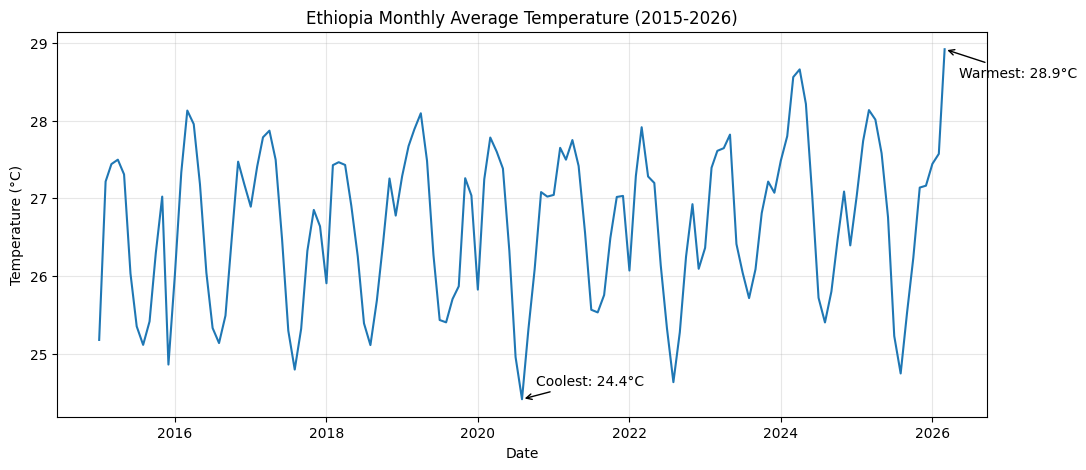

In [12]:
monthly_temp = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], linewidth=1.5)

# Annotate warmest and coolest months
max_row = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
min_row = monthly_temp.loc[monthly_temp['T2M'].idxmin()]
plt.annotate(f"Warmest: {max_row['T2M']:.1f}°C", xy=(max_row['Date'], max_row['T2M']), 
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Coolest: {min_row['T2M']:.1f}°C", xy=(min_row['Date'], min_row['T2M']),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title('Ethiopia Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.show()

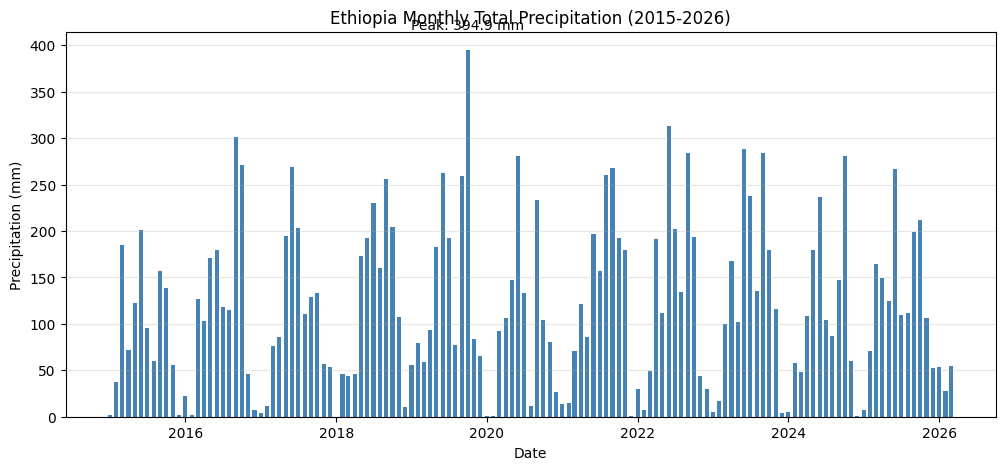

In [13]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], width=20, color='steelblue')
peak_month = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f"Peak: {peak_month['PRECTOTCORR']:.1f} mm", 
             xy=(peak_month['Date'], peak_month['PRECTOTCORR']),
             xytext=(0, 15), textcoords='offset points', ha='center')
plt.title('Ethiopia Monthly Total Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(alpha=0.3, axis='y')
plt.show()

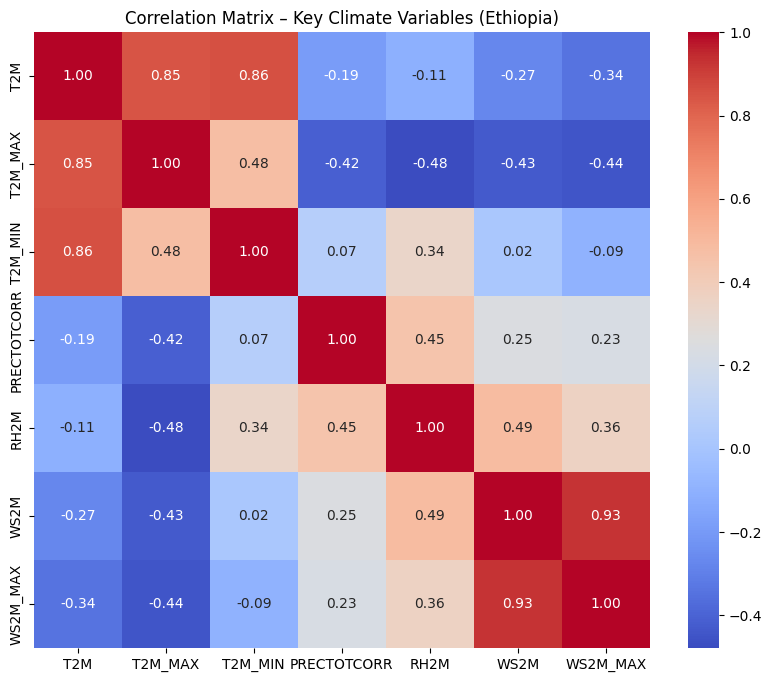

In [14]:
plt.figure(figsize=(10,8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix – Key Climate Variables (Ethiopia)')
plt.show()

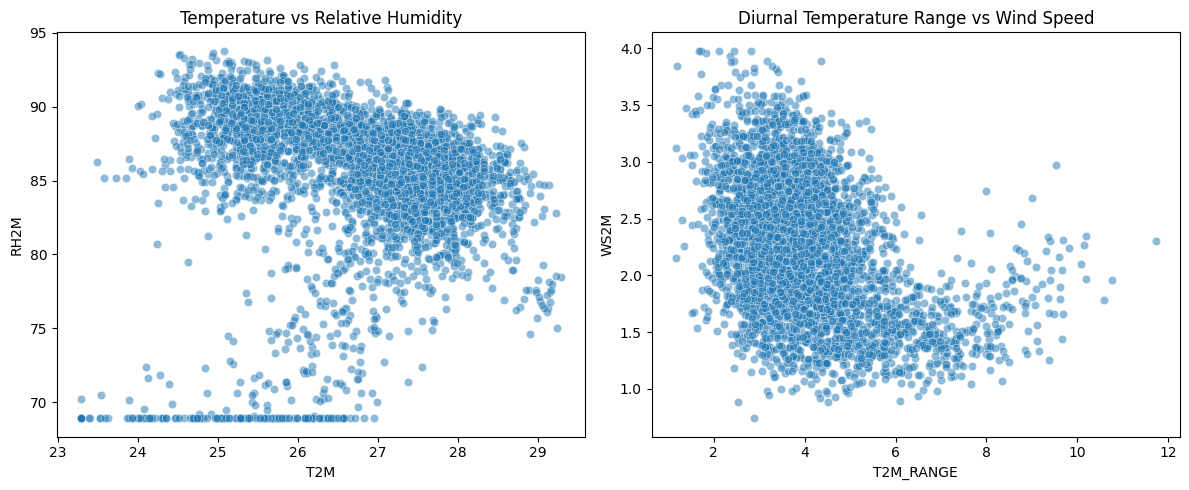

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5, ax=axes[1])
axes[1].set_title('Diurnal Temperature Range vs Wind Speed')
plt.tight_layout()
plt.show()

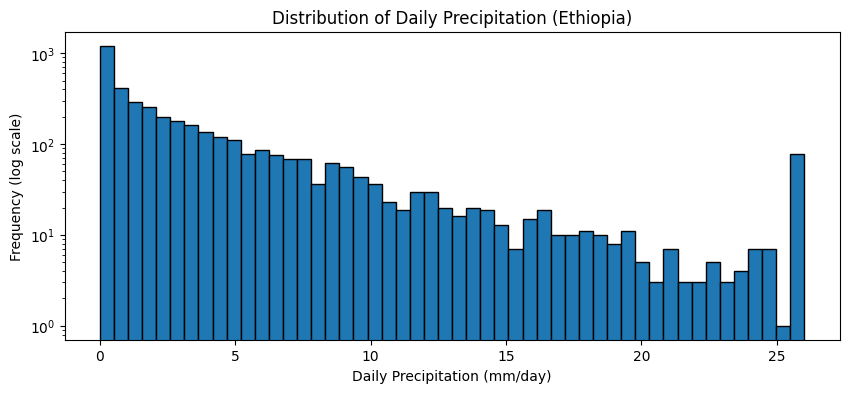

In [16]:
plt.figure(figsize=(10,4))
plt.hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
plt.yscale('log')   # because precipitation is often highly skewed
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Daily Precipitation (Ethiopia)')
plt.show()

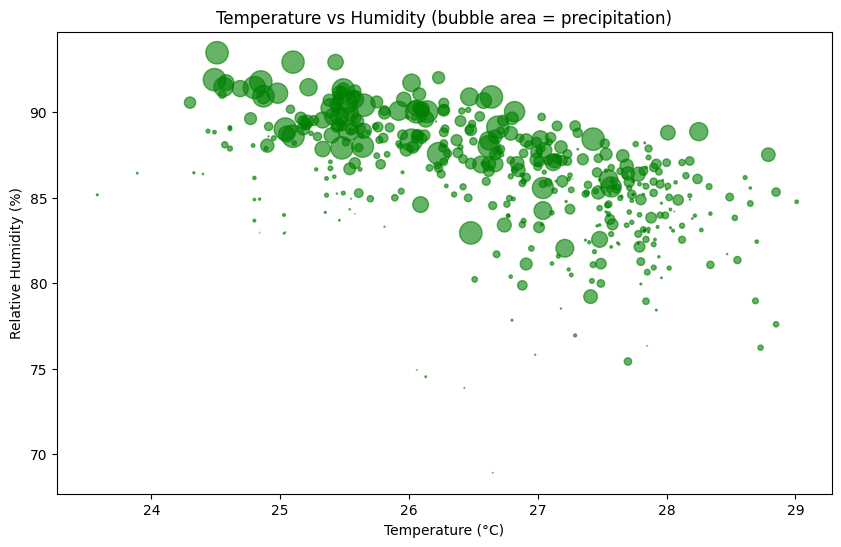

In [17]:

sample = df.sample(min(500, len(df)))
plt.figure(figsize=(10,6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.6, c='green')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (bubble area = precipitation)')
plt.show()